In [1]:
from tmu.models.classification.vanilla_classifier import TMClassifier
import numpy as np
import os 
import logging
import config
import pickle
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_adaptive_gaussian_thresholding_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, save_heatmap_images, build_save_path, load_raw_maps_and_plot_heatmap

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-10 21:30:37,462 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-05-10 21:30:37,467 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-05-10 21:30:37,481 - matplotlib - DEBUG - interactive is False
2026-05-10 21:30:37,482 - matplotlib - DEBUG - platform is linux
2026-05-10 21:30:37,538 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-05-10 21:30:37,540 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.ADAPTIVE_GAUSSIAN
CURRENT_DATASET = config.BREASTMNIST
CURRENT_RESOLUTION = 1 
specialist_name = ["Adaptive Gaussian"]

In [3]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [4]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_adaptive_gaussian_thresholding_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test)

In [5]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_val  = Y_val.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)

In [33]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="fbeta", pos_label=0)

[I 2026-04-12 19:53:19,024] A new study created in memory with name: no-name-a0a997df-50ca-424b-ba42-9277abe5d07b
[W 2026-04-12 19:53:26,659] Trial 0 failed with parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/coder/masters_thesis/venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/home/coder/masters_thesis/utils/optuna.py", line 129, in objective
    tm_trial.fit(X_train, Y_train, epochs=1, incremental=True)
  File "/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tmu/models/classification/vanilla_classifier.py", line 403, in fit
    history: dict = self._fit_sample(
                    ^^^^^^^^^^^^^^^^^
  File "/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tmu/models/classification/vanilla_classifier.py", line 343, 

KeyboardInterrupt: 

In [ ]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/adaptive_gaussian.json")

Best F1 score macro accuracy: 0.8571428571428571
Best hyperparameters: {'s': 4.0, 'T': 7500, 'patch_size': 7, 'max_included_literals': 32}
Best Optuna results saved to hyperparameters/adaptive_gaussian.json


In [6]:
best_value, best_params = load_optuna_best_results("hyperparameters/adaptive_gaussian.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [ ]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="BreastMNIST_Adaptive_Gaussian",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 76.92% (15.86s)


#2 Accuracy: 78.85% (15.68s)


#3 Accuracy: 81.41% (14.43s)


#4 Accuracy: 76.92% (13.66s)


...

#96 Accuracy: 78.85% (9.39s)


#97 Accuracy: 80.77% (9.33s)


#98 Accuracy: 80.77% (8.96s)


#99 Accuracy: 78.85% (8.94s)


#100 Accuracy: 78.21% (8.93s)


In [7]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "BreastMNIST_Adaptive_Gaussian_Specialist.pkl")

In [ ]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [8]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

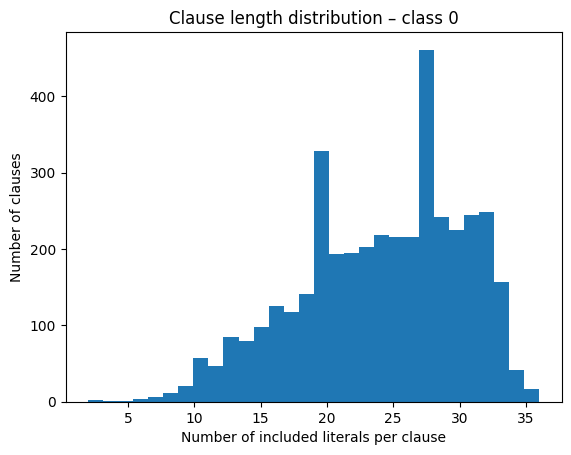

Class 0: median=25.0, mean=24.1, std=6.1


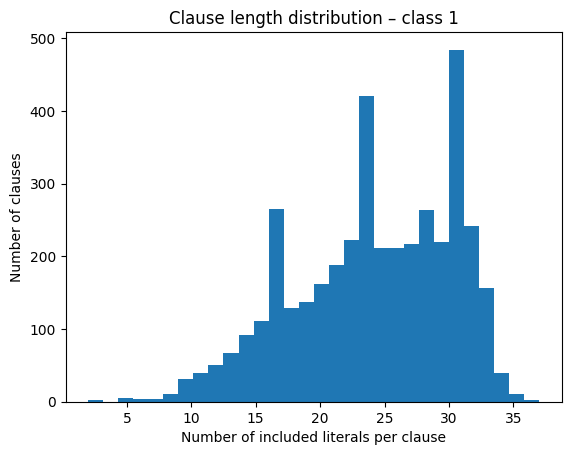

Class 1: median=25.0, mean=24.1, std=6.1


In [ ]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 78.21%
2026-05-10 21:30:47,306 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 21:30:47,309 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 21:30:47,330 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x74bbcc73d8b0>
Saved to saved_confusion_matrices/breast_adaptive_gaussian.svg


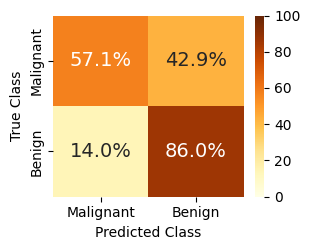

In [9]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="BreastMNIST_Adaptive_Gaussian", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, figsize=(3.2, 2.6), annot_fontsize=14, cmap = "YlOrBr") 

# Class 0 Local Examples

In [ ]:
# image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
# print(f"Selected image index: {image_index}")
# print(f"True class: {Y_test[image_index]}")
# print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

0
2026-04-10 15:15:04,800 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 15:15:04,804 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 10  |  predicted class: 0
2026-04-10 15:15:04,836 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eb204164230>
Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_lh_c0_s10_aggr.svg


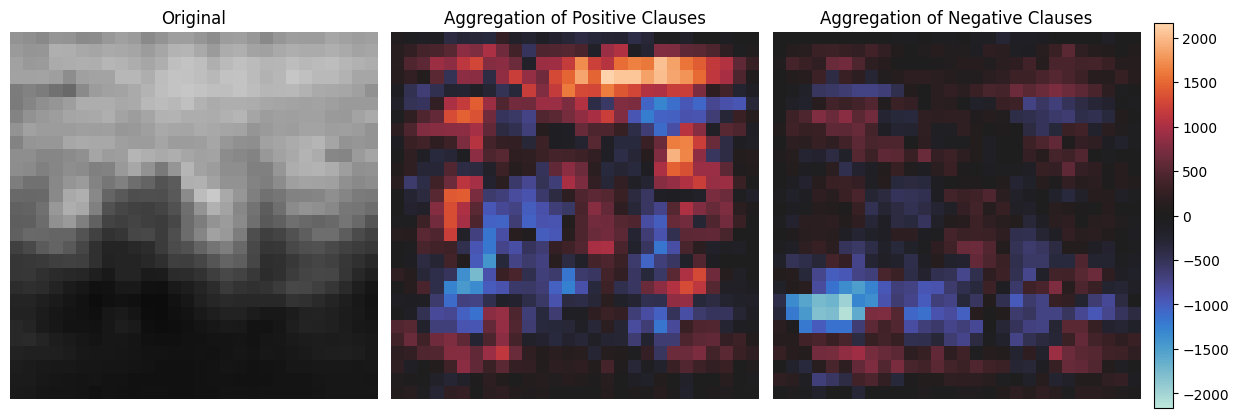

Visualizing sample 10  |  predicted class: 0
2026-04-10 15:15:08,496 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eb1dfb44980>
Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_lh_c0_s10_chan.svg


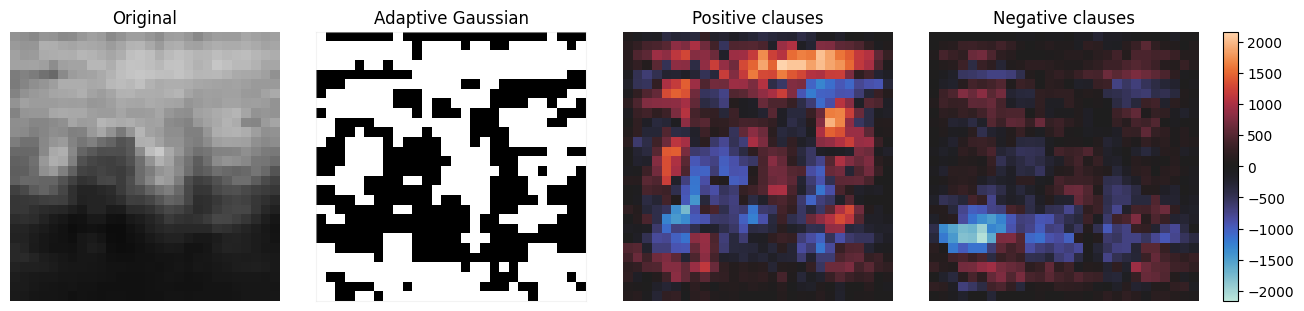

In [ ]:
image_index =  10
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0
Visualizing sample 13  |  predicted class: 0
2026-04-10 15:15:12,331 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eb20462a2d0>
Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_lh_c0_s13_aggr.svg


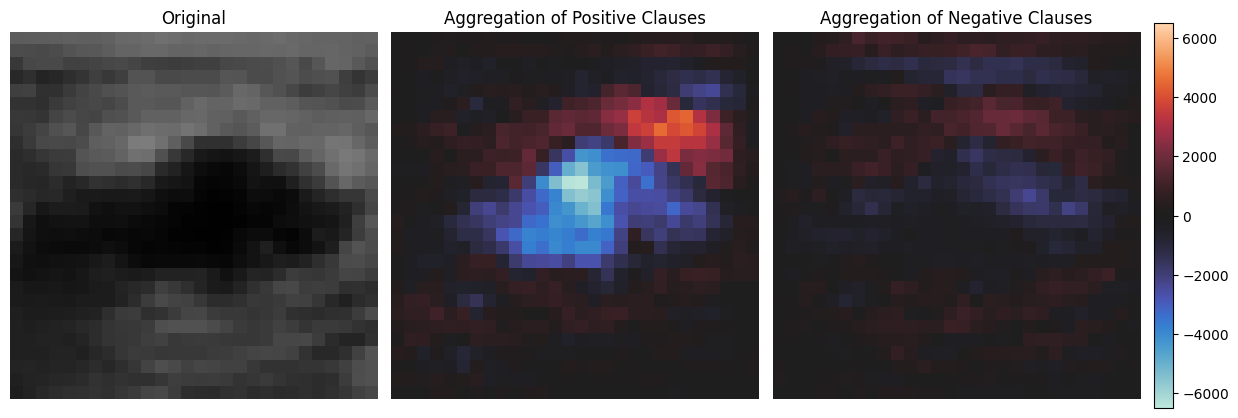

Visualizing sample 13  |  predicted class: 0
2026-04-10 15:15:16,046 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eb1dfad3d10>
Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_lh_c0_s13_chan.svg


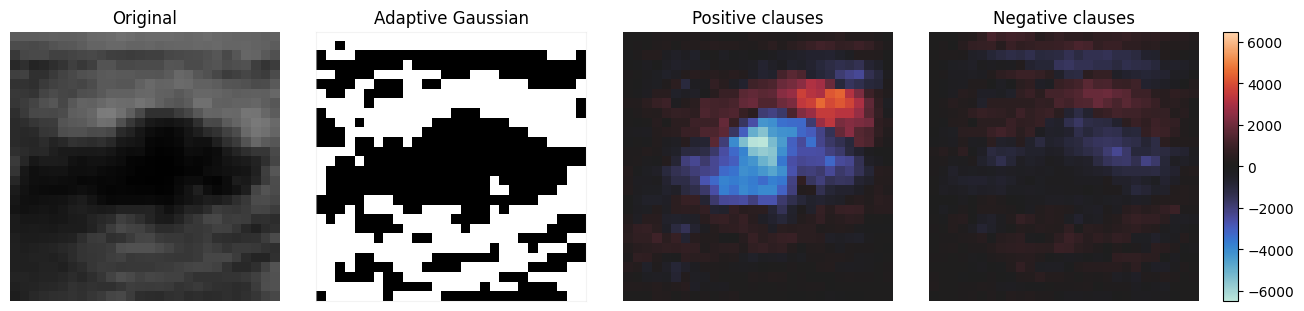

In [ ]:
image_index =  13
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0
Visualizing sample 35  |  predicted class: 0
2026-04-10 15:15:19,521 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eb1df8036b0>
Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_lh_c0_s35_aggr.svg


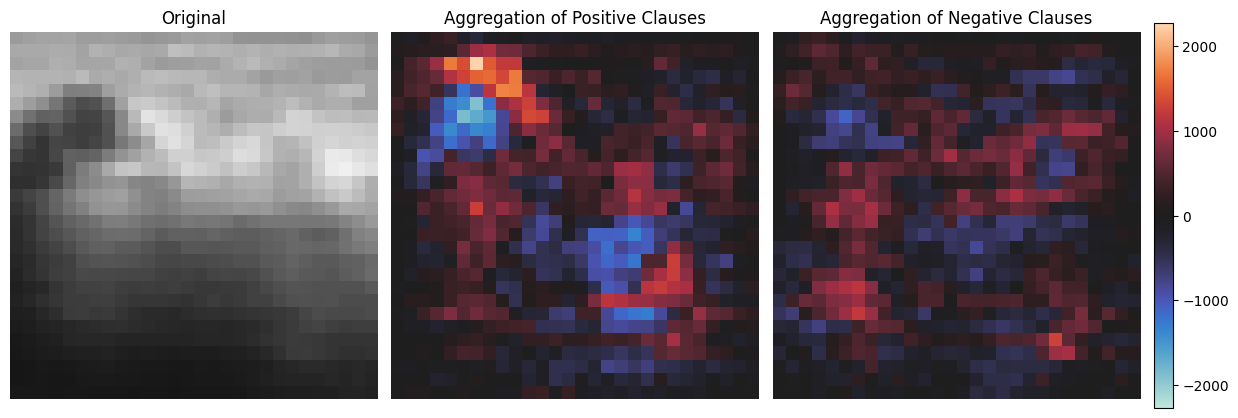

Visualizing sample 35  |  predicted class: 0
2026-04-10 15:15:22,992 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eb1df8dc410>
Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_lh_c0_s35_chan.svg


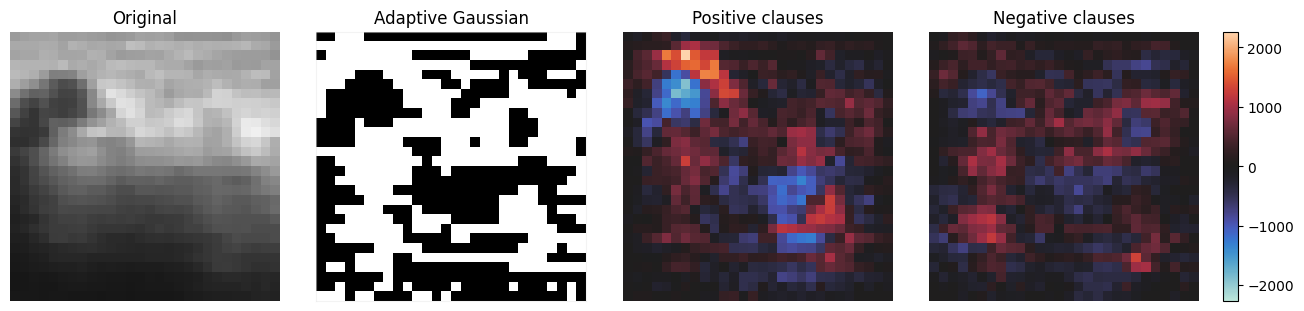

In [ ]:
image_index =  35
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Class 1 Local Examples

In [ ]:
# image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
# print(f"Selected image index: {image_index}")
# print(f"True class: {Y_test[image_index]}")
# print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

1
Visualizing sample 73  |  predicted class: 1
2026-04-10 15:15:26,934 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eb1df6211f0>
Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_lh_c1_s73_aggr.svg


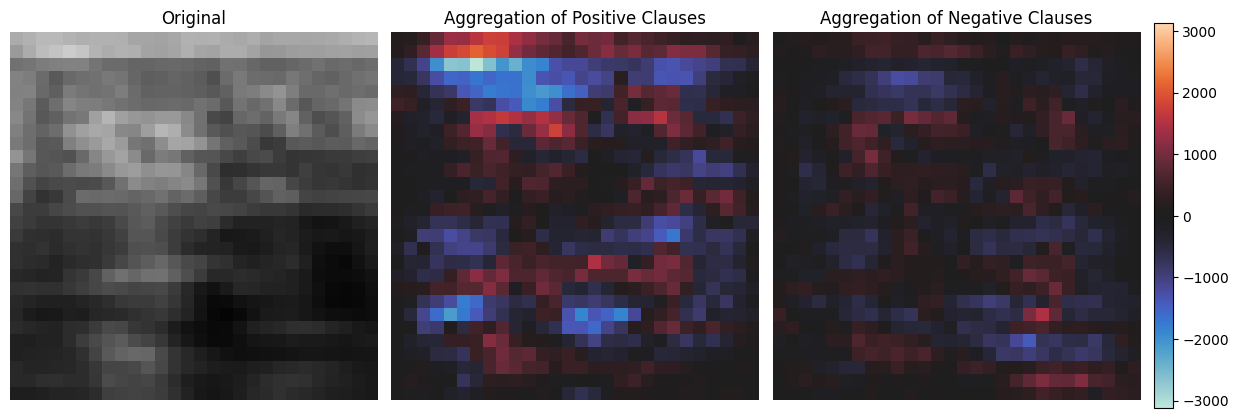

Visualizing sample 73  |  predicted class: 1
2026-04-10 15:15:30,923 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eb1df7c3bc0>
Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_lh_c1_s73_chan.svg


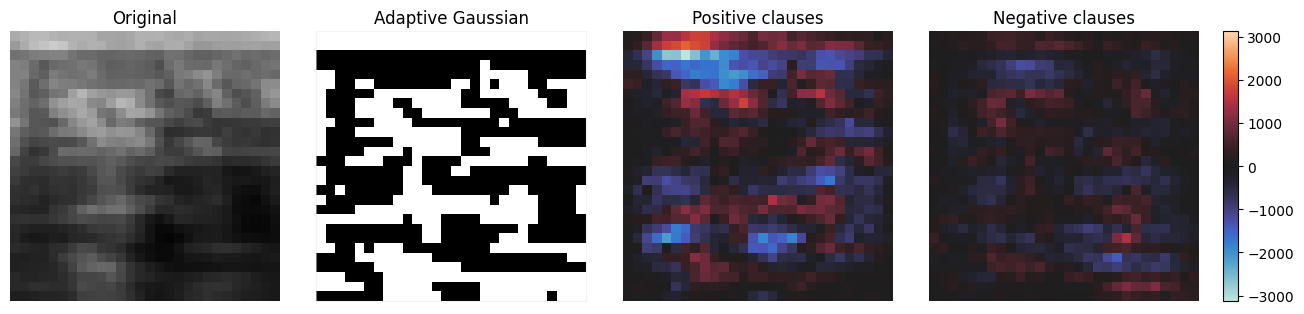

In [ ]:
image_index =  73
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

1
Visualizing sample 5  |  predicted class: 1
2026-04-10 15:15:34,625 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eb1df3221b0>
Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_lh_c1_s5_aggr.svg


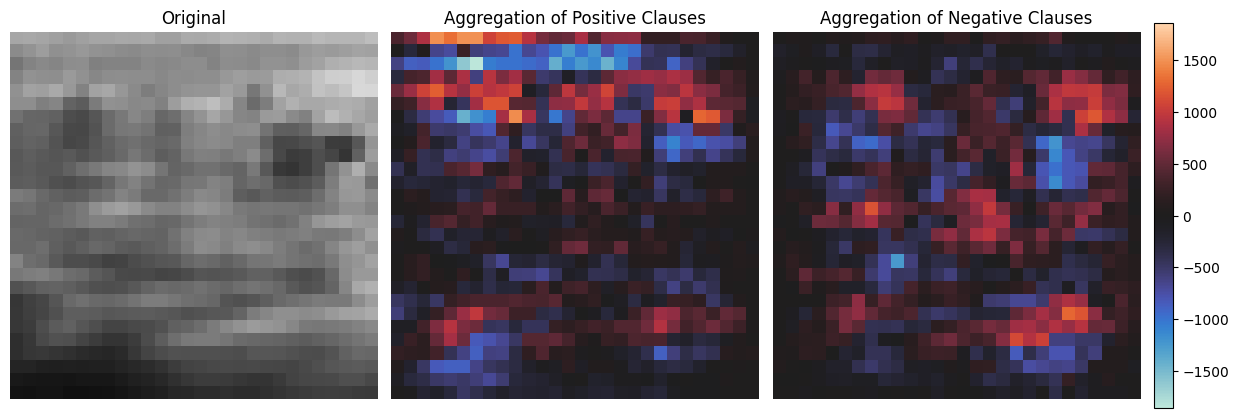

Visualizing sample 5  |  predicted class: 1
2026-04-10 15:15:38,297 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eb1df4f1820>
Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_lh_c1_s5_chan.svg


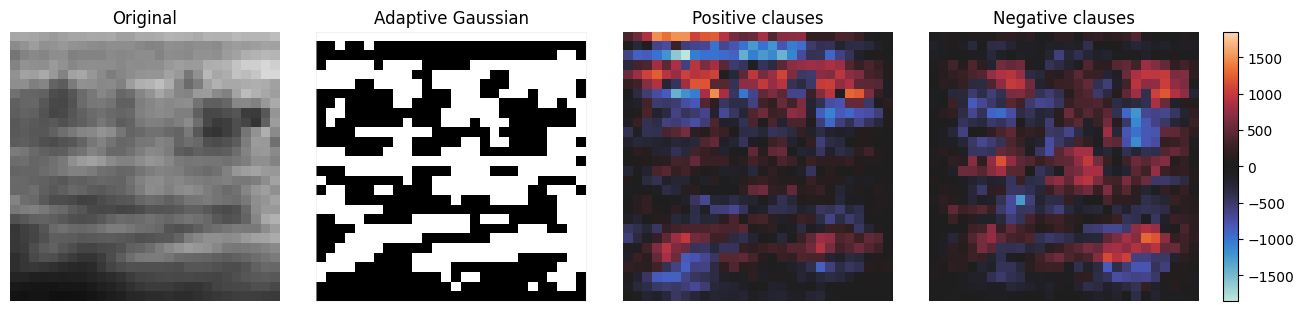

In [ ]:
image_index =  5
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Global Heatmap

In [ ]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 0

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 18:46:51,953 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 18:46:51,956 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 18:46:51,979 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x71cfcce56ea0>
Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_gh_c0.svg


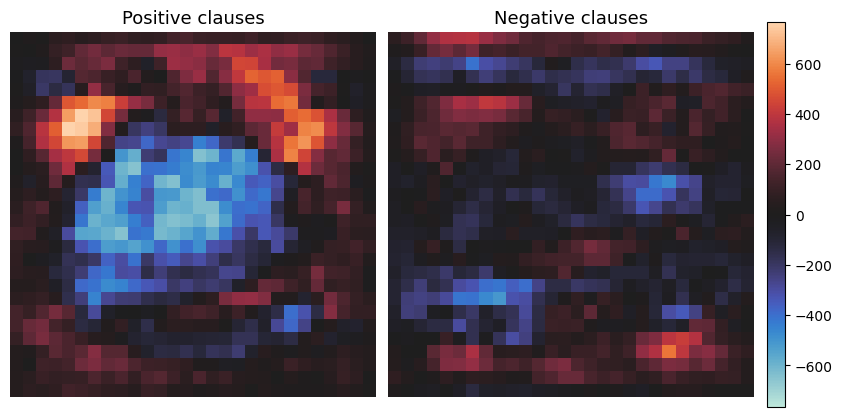

pos shape: (28, 28), min: -664.17, max: 765.92
neg shape: (28, 28), min: -509.00, max: 560.00
saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_gh_c0.svg


In [ ]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

In [ ]:
# target_class = 1

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)

# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 18:46:55,768 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x71cfc7dc68d0>


Saved to saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_gh_c1.svg


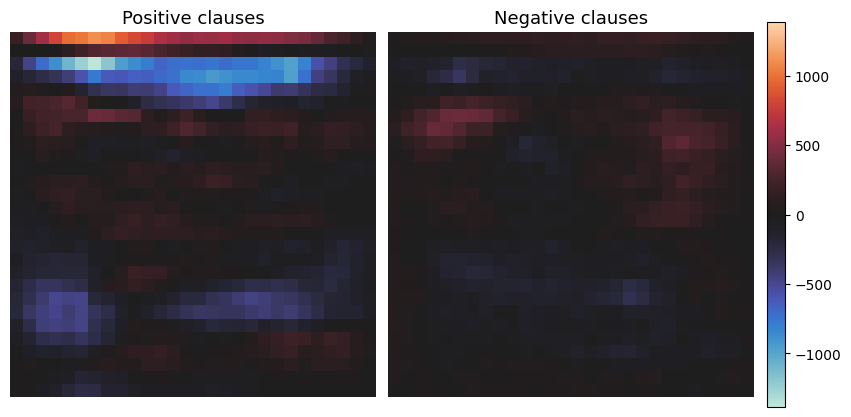

pos shape: (28, 28), min: -1387.16, max: 1109.93
neg shape: (28, 28), min: -355.60, max: 413.36
saved_heatmaps/adaptive_gaussian/breast_adaptive_gaussian_gh_c1.svg


In [ ]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)